In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
import scipy as sp
from IPython.display import display, Math
from multiprocessing import Pool
import pandas as pd

#### Population transfer

In [2]:
# drive_phi, drive_theta = False, True
drive_phi, drive_theta = True, False
truc1 = 100

folder = '../../data/3ncut_one_zeropi/'
truncation=1000
eval0 = 2*np.pi* scq.read(folder + f'zeropi_0_specdata_truc={truncation}_3ncut.h5').energy_table
n_theta0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_theta_truc={truncation}_3ncut.h5').matrixelem_table
n_phi0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_phi_truc={truncation}_3ncut.h5').matrixelem_table
eval0 = eval0 - eval0[0]
if drive_phi:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = n_phi0
if drive_theta:
    w_trans_1 = eval0[7] - eval0[0]
    w_trans_2 = eval0[7] - eval0[2]
    drive_term = n_theta0

In [3]:
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [39.991616, 0.105045, 0.028058, 0.002171, 0.003988] # theta
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [120.004766,0.209273,0.104767,0.341188,0.360503] # phi
H0 = qt.Qobj(np.diag(eval0))
hilbert_space = np.arange(truc1).tolist()
tlist = np.linspace(0, tg,  num=10* int(tg) )  # total time
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        }

H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drive_gauss_A],
                        [drive_truc, ut.drive_gauss_B],]
states = [qt.basis(truc1, i) for i in range(truc1)]

result = {}
logi_state = [0, 2]
logi_index = [hilbert_space.index(i) for i in logi_state]
for jdx, state_j in enumerate(logi_index):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=qt.Options(store_states=True, nsteps=1e4)  )

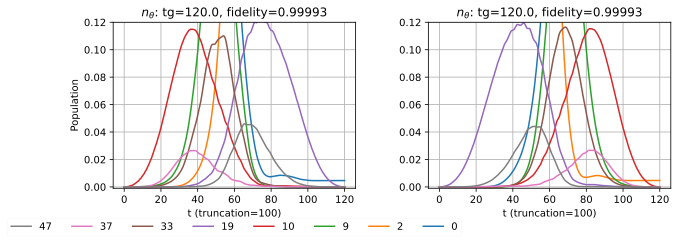

In [4]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
state_phi = [0, 2, 9, 10, 19, 33, 37, 47] # phi
state_theta = [0, 2, 7, 25] # theta
state_interest = state_theta if drive_theta else state_phi
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        if state in state_interest:
            ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99993')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

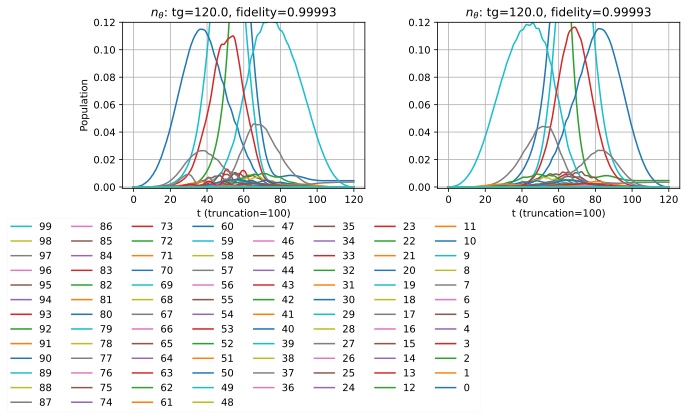

In [5]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        # if state in state_interest:
        ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99993')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

In [6]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [10]:
pop = np.array(result[0].expect)
print(np.shape(pop))
pop_integral = pop.sum(axis=1)
print(np.shape(pop_integral))

(100, 1200)
(100,)


In [16]:

# Example NumPy array
arr = pop_integral

# Get the indices of the top 10 largest values
top_indices = np.argsort(arr)[-20:]  # Sort and take the last 10 indices

# Get the top 10 largest values
top_values = arr[top_indices]

# Sorting in descending order (optional)
sorted_order = np.argsort(top_values)[::-1]
top_indices = top_indices[sorted_order]
top_values = top_values[sorted_order]

print("Top 10 values:", top_values.tolist())
print("State of large population:", top_indices.tolist())


Top 10 values: [536.7426346882427, 464.62107963799406, 49.15375992352576, 44.31839240867677, 36.54479054212087, 25.80413264135733, 11.092087366299413, 7.088375232925662, 3.447575546080623, 2.875881356380311, 2.87424863811283, 2.098440201544163, 1.6665115718810155, 1.488242527346707, 1.4742892187864425, 1.359625387768136, 1.0506113516559124, 0.8889950235378652, 0.882588776100109, 0.5740066505302972]
State of large population: [2, 0, 9, 19, 10, 33, 47, 37, 15, 57, 42, 23, 25, 28, 40, 70, 69, 83, 31, 51]


In [22]:
pop = np.array(result[0].expect)
pop_interest = pop[state_interest, :]
pop_other = np.delete(pop, state_interest, axis=0).sum(axis=0)
pop_save = np.vstack((tlist,pop_interest, pop_other)).T
col_phi = ['tg'] + [f'{i}' for i in state_phi] + ['other']
col_theta = ['tg'] + [f'{i}' for i in state_theta] + ['other']
columns = col_theta if drive_theta else col_phi
df = pd.DataFrame(pop_save, columns=columns)
# df.to_csv('data/population_theta.txt', sep=',', index=False, header=True)

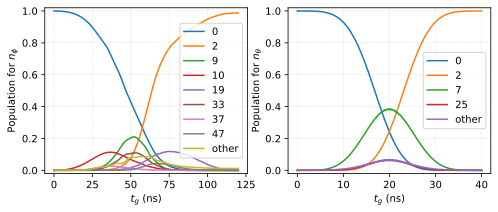

In [23]:
from scipy.ndimage import gaussian_filter
pop_phi = pd.read_csv('data/population_phi.txt').to_numpy()
pop_theta = pd.read_csv('data/population_theta.txt').to_numpy()

col_phi = ['tg'] + [f'{i}' for i in state_phi] + ['other']
col_theta = ['tg'] + [f'{i}' for i in state_theta] + ['other']

x_size, y_size = 8, 3
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(x_size, y_size))
# plt.subplots_adjust(wspace=0.5)
for i in np.arange(1, pop_phi.shape[1]):
    ax[0].plot( pop_phi[:,0], gaussian_filter( pop_phi[:,i], 3), '-', label=col_phi[i])
for i in np.arange(1, pop_theta.shape[1]):
    ax[1].plot( pop_theta[:,0], gaussian_filter( pop_theta[:,i], 3), '-', label=col_theta[i])
ax[0].set_ylabel(r'Population for $n_\phi$')
ax[1].set_ylabel(r'Population for $n_\theta$')

for i in range(2):
    # ax[i].set_xlim(-25, 25)
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].legend()
    ax[i].grid(linewidth=0.2, linestyle='--')
    ax[i].set_xlabel(r'$t_g$ (ns)')



In [ ]:
=

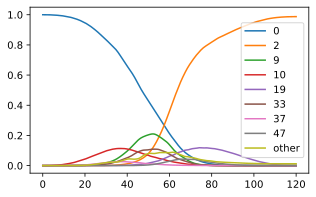

In [129]:
df_import = pd.read_csv('data/population_phi.txt').to_numpy()
fig, ax = plt.subplots(figsize=(5,3), nrows=1, ncols=1)
for i in np.arange(1, df_import.shape[1]):
    plt.plot(df_import[:,0], gaussian_filter( df_import[:,i], 3), label=columns[i] )
plt.legend()

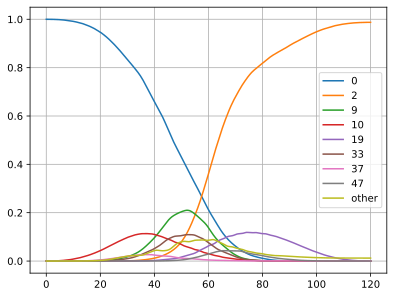

In [133]:
df_phi = pd.read_csv('data/population_phi.txt').to_numpy()
for i in np.arange(1, df_phi.shape[1]):
    plt.plot(df_phi[:,0], gaussian_filter( df_phi[:,i], 3), label=col_phi[i] )
plt.legend()
plt.grid()

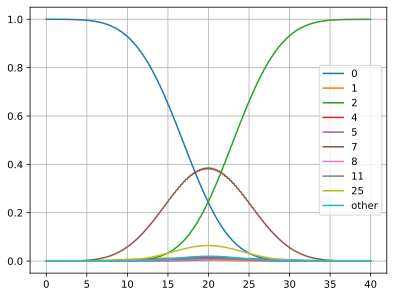

In [135]:
df_import = pd.read_csv('data/population_theta.txt').to_numpy()
for i in np.arange(1, df_import.shape[1]):
    plt.plot(df_import[:,0], gaussian_filter( df_import[:,i], 3), label=col_theta[i] )
plt.legend()
plt.grid()


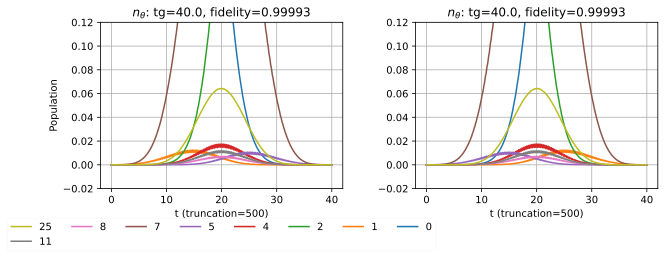

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        if state in [0,2,7,25,1,4,5,8,11]:
            ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    ax[jdx].set_ylim(-0.02,0.12)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99993')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

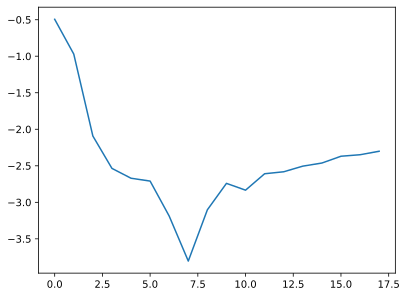

In [ ]:
f = np.array([-0.49421317483994787, -0.9706932154710265, -2.092269677304886, -2.53563689914273 ,
-2.670487401445233, -2.70930437857873, -3.188638051596233, -3.804179904944996 ,
-3.1025622906210293, -2.740578639545418, -2.8338201283087203, -2.6089346950187475 ,
-2.581891652986029, -2.504865558652494, -2.4621674495232826, -2.3691757206514104 ,
-2.348579176593928, -2.300682881811202 ,])

plt.plot(f)

### Fidelity

In [8]:
nsteps = 1e9
def sesolve_parallel(argz):
    H, psi0, tlist, pulse_args, options = argz
    return psi0, qt.sesolve(H, qt.basis(H[0].shape[0], psi0), tlist, options=options, args=pulse_args)

def xgate_fidelity_fast(argz):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

    states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
    H0_truc = ut.truncate_2(H0, hilbert_space)
    drive_truc = ut.truncate_2(drive_term, hilbert_space)
    H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                            [drive_truc, ut.drag_B],]

    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': alpha_B }
    tlist = np.linspace(0, tg,  num=100)  # total time
    options = qt.Options(num_cpus=1, nsteps=nsteps)

    sesolve_args = []
    logical_states = [0, 2]
    logical_idx = [hilbert_space.index(s) for s in logical_states]
    for i in logical_idx:
        sesolve_args.append([H_qbt_drive, i, tlist, pulse_args, options])

    prop = np.zeros((len(hilbert_space), len(logical_states)), dtype=np.complex128)
    if n_cpu > 1:
        pool = Pool(processes=n_cpu)
        for i, res in pool.imap_unordered(sesolve_parallel, sesolve_args):
            prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
    for se_arg in sesolve_args:
        i, res = sesolve_parallel(se_arg)
        prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
    prop = qt.Qobj(prop)

    Uc = ut.truncate_2(prop, [hilbert_space.index(psi) for psi in logical_states])
    fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())
    return np.log10(1-fidelity)


def xgate_fidelity(argz):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

    states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
    H0_truc = ut.truncate_2(H0, hilbert_space)
    drive_truc = ut.truncate_2(drive_term, hilbert_space)
    H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                            [drive_truc, ut.drag_B],]

    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': alpha_B }
    tlist = np.linspace(0, tg,  num=100)  # total time
    options =qt.Options(num_cpus=1, nsteps=nsteps)
    if n_cpu==1:
        props = qt.propagator(options=options,
                             H=H_qbt_drive,
                            t=tlist,
                            args=pulse_args,
                            )  # get the propagator at the final time step

        # num=100* int(np.max([tg, len(hilbert_space) ]))
        # options =qt.Options( nsteps=100*num)
        # prop = qt.propagator( H=H_qbt_drive,
        #                         t=tg,
        #                         args=pulse_args,
        #                         options=options,
        #                         # num_cpus=n_cpu,
        #                         # parallel=True,
        #                         )  # get the propagator at the final time step
    else:
        props = qt.propagator( H=H_qbt_drive,
                                t=tlist,
                                args=pulse_args,
                                options=options,
                                num_cpus=n_cpu,
                                parallel=True,
                                )  # get the propagator at the final time step
    prop = props[-1]
    # Max non logical + intermediate state population
    index_2 = hilbert_space.index(2)
    state_logi = [states[0], states[index_2]]
    Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in state_logi]
            for s2 in state_logi  ])
    fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())
    return np.log10(1-fidelity)

In [9]:
hspace_full = list(np.arange(20))
[tg, amp_A, amp_B, detune_A, detune_B] = [502.481, 0.0275548, 0.04704444, 0.0159511, 0.0173680]
n_cpu = 1
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_full, n_cpu, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]


In [10]:
# f_fast = 1 - 10**xgate_fidelity_fast(argz)
# print('f_fast=', f_fast)

In [11]:
# f_old = 1 - 10**xgate_fidelity(argz)
# print('f_old=', f_old)


In [12]:
[H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                        [drive_truc, ut.drag_B],]

pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
            'alpha_A': alpha_A,
            'alpha_B': alpha_B }
tlist = np.linspace(0, tg,  num=100)  # total time
options = qt.Options(num_cpus=1, nsteps=nsteps)

sesolve_args = []
logical_states = [0, 2]
logical_idx = [hilbert_space.index(s) for s in logical_states]
for i in logical_idx:
    sesolve_args.append([H_qbt_drive, i, tlist, pulse_args, options])

prop = np.zeros((len(hilbert_space), len(logical_states)), dtype=np.complex128)
if n_cpu > 1:
    pool = Pool(processes=n_cpu)
    for i, res in pool.imap_unordered(sesolve_parallel, sesolve_args):
        prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
for se_arg in sesolve_args:
    i, res = sesolve_parallel(se_arg)
    prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
prop = qt.Qobj(prop)

Uc = ut.truncate_2(prop, [hilbert_space.index(psi) for psi in logical_states])
fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())

In [ ]:
hilbert_space = [0, 2, 9, 10, 11, 15, 16, 18, 19, 25, 31, 33, 37,
                 46, 53, 55, 57, 69, 76, 77, 83, 91, 92, 95, 100, 121, 126, 154]
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
drive_truc = drive_truc.tidyup(atol=1e-5)
# np.savetxt("n_theta_truc_4.txt", drive_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV
# np.savetxt("H0_truc_4.txt", H0_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV
